La hora dada de print(time) tiene la forma 2025-09-01T17:00:29.944072Z. ¿Qué significa la letra Z al final?

Significa "Zulu" y se refiere a la hora universal UTC (Coordinated Universal Time).

Las primeras dos letras de cada componente de un sismograma indica el nombre de la red de estaciones que se usó

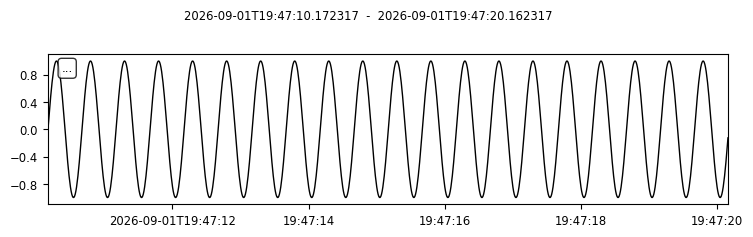

In [2]:
import numpy as np
from obspy import Trace
from obspy import UTCDateTime
dt = 0.01 # delta en segundos (=> Fs = 100 Hz)
npts = 1000 #número de muestras (~10s de registro)
t = np.arange(npts) * dt # vector de tiempo
f = 2.0 # frecuencia de la señal (Hz)
sine = np.sin(2*np.pi*f*t) # señal senoidal
tr_sine = Trace(sine) # traza sismológica con la señal senoidal
tr_sine.stats.sampling_rate = 1/dt # frecuencia de muestreo (Hz)
tr_sine.stats.starttime = UTCDateTime.now() # tiempo de inicio de la traza
tr_sine.plot() # graficar la traza sismológica
tr_sine.write("seno.sac", format="SAC") # guardar la traza en formato SAC

En el código anterior, la línea 9 es vital, debido a que es esta la responsable de transformar el seno definido en una señal sísmica de modo que se puede aplicar las funciones de obspy a la traza.

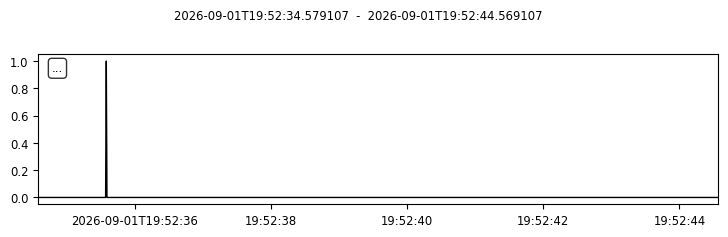

In [3]:
import numpy as np
from obspy import Trace
from obspy import UTCDateTime
dt = 0.01 # delta en segundos (=> Fs = 100 Hz)
npts = 1000 #número de muestras (~10s de registro)
imp = np.zeros(npts) # señal de impulso
imp[int(1/dt)] = 1.0 # impulso unitario en t=1s
tr_delta = Trace(imp) # traza sismológica con la señal de impulso
tr_delta.stats.sampling_rate = 1/dt # frecuencia de muestreo (Hz)
tr_delta.stats.starttime = UTCDateTime.now() # tiempo de inicio de la traza
tr_delta.plot() # graficar la traza sismológica
tr_delta.write("delta.sac", format="SAC") # guardar la traza en formato SAC

In [37]:
from obspy import UTCDateTime
time = UTCDateTime("2012-09-07T12:15:00-07:00") # fecha y hora en formato UTC
print(time) # imprimir la fecha y hora en formato UTC
time1 = UTCDateTime.now()
tt = time1 - time # diferencia de tiempo en segundos
print(tt) # imprimir la diferencia de tiempo en segundos
#print(time) # imprimir la fecha y hora actual en formato UTC

2012-09-07T19:15:00.000000Z
441248061.062117


**Metadatos: Archivo simple**

Un sismograma es una serie de tiempo (voltaje, o cuentas digitales, o aceleración del suelo, o velocidad del suelo, etc.), más los metadatos asociados.

In [38]:
from obspy import read
st = read("seno.sac") # leer la traza en formato SAC
print(st) # imprimir la información de la traza
tr = st[0] # obtener la primera traza del Stream
print(tr.stats) # imprimir la información de la traza

1 Trace(s) in Stream:
... | 2026-09-01T19:47:10.172317Z - 2026-09-01T19:47:20.162317Z | 100.0 Hz, 1000 samples
         network: 
         station: 
        location: 
         channel: 
       starttime: 2026-09-01T19:47:10.172317Z
         endtime: 2026-09-01T19:47:20.162317Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 1000
           calib: 1.0
         _format: SAC
             sac: AttribDict({'delta': np.float32(0.01), 'depmin': np.float32(-0.9980267), 'depmax': np.float32(0.9980267), 'scale': np.float32(1.0), 'b': np.float32(0.000317), 'e': np.float32(9.990316), 'depmen': np.float32(3.907985e-17), 'nzyear': np.int32(2026), 'nzjday': np.int32(244), 'nzhour': np.int32(19), 'nzmin': np.int32(47), 'nzsec': np.int32(10), 'nzmsec': np.int32(172), 'nvhdr': np.int32(6), 'npts': np.int32(1000), 'iftype': np.int32(1), 'iztype': np.int32(9), 'leven': np.int32(1), 'lpspol': np.int32(1), 'lovrok': np.int32(1), 'lcalda': np.int32(0)})


- Un stream (st) es un contenedor de una o más trazas, donde se puede manejar múltiples canales a la vez

- Un trace (tr) es una serie de tiempo individual, con sus metadatos

In [39]:
tr.stats.sac['stla'] =-36.83
tr.stats.sac['stlo'] =-73.05
tr.stats.sac['stel'] = 15.0
tr.stats.sac['stdp'] = 2.0
tr.stats.network = "XX"
tr.stats.station = "TEST"
tr.stats.location = "00"
tr.stats.channel = "BHZ"
print(tr.stats)
tr.write("seno.sac", format="SAC")

         network: XX
         station: TEST
        location: 00
         channel: BHZ
       starttime: 2026-09-01T19:47:10.172317Z
         endtime: 2026-09-01T19:47:20.162317Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 1000
           calib: 1.0
         _format: SAC
             sac: AttribDict({'delta': np.float32(0.01), 'depmin': np.float32(-0.9980267), 'depmax': np.float32(0.9980267), 'scale': np.float32(1.0), 'b': np.float32(0.000317), 'e': np.float32(9.990316), 'depmen': np.float32(3.907985e-17), 'nzyear': np.int32(2026), 'nzjday': np.int32(244), 'nzhour': np.int32(19), 'nzmin': np.int32(47), 'nzsec': np.int32(10), 'nzmsec': np.int32(172), 'nvhdr': np.int32(6), 'npts': np.int32(1000), 'iftype': np.int32(1), 'iztype': np.int32(9), 'leven': np.int32(1), 'lpspol': np.int32(1), 'lovrok': np.int32(1), 'lcalda': np.int32(0), 'stla': -36.83, 'stlo': -73.05, 'stel': 15.0, 'stdp': 2.0})


Estos son los registros del terremoto de Maule, 2010 (MW8.8) en el aceler´ometro instalado en Colegio
Concepci´on, San Pedro. Los datos muestran la aceleraci´on en cm/s/s de los tres componentes del sensor:
vertical, norte-sur y este-oeste.

In [ ]:
from obspy import read
st = read('*CCSP*sac')
st.plot()

In [ ]:
from obspy import read
import numpy as np
import matplotlib.pyplot as plt
st = read("*CCSP*.sac").sort(keys=["channel"])
trZ = st.select(channel="*Z")[0]
trN = st.select(channel="*N")[0]
trE = st.select(channel="*E")[0]
plt.ion()
plt.figure(figsize=(10,5))
t = trZ.times(reftime=trZ.stats.starttime)
plt.plot(t, trZ.data, label=trZ.id)
plt.plot(t, trN.data, label=trN.id)
plt.plot(t, trE.data, label=trE.id)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleraci´on [cm/s/s]")
plt.title("Maule 2010 en CCSP")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

Para hacer un zoom sobre los primeros 20 segundos del registro

In [ ]:
ax3.set_xlim(0, 20)

Tambi´en, se puede guardar directamente en formatos .pdf .png, .svg, .eps, .jpg

In [ ]:
plt.savefig('mauleccsp.pdf')